In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp3_label_only/exp3_label_only.sh

-rw------- 1 root root 8665 Apr  5 12:24 experiments/exp3_label_only/exp3_label_only.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp3_label_only/exp3_label_only.sh

Experiment 3 — Phase 1: Label Only (Pure Legendre Embedding)
What is being tested:
  Embedding : value + Legendre position only
  Formula   : X'_i = X_i + P_i
  No temporal embedding, no distance decay, no alpha
Fixed config  : scaling=True (hardcoded in embed.py)
Seed          : 2021 (Phase 1 single seed)
Pred lengths  : 96, 192 (Phase 1 short + mid horizon)
Total runs    : 2
Decision after: compare MSE vs best previous experiment
Start: Sun Apr  5 12:29:10 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/2: exp3_ph1_ETTh1_legendre_pred96_seed2021
pred_len=96 | seed=2021 | config=legendre_only
Start: Sun Apr  5 12:29:14 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_l

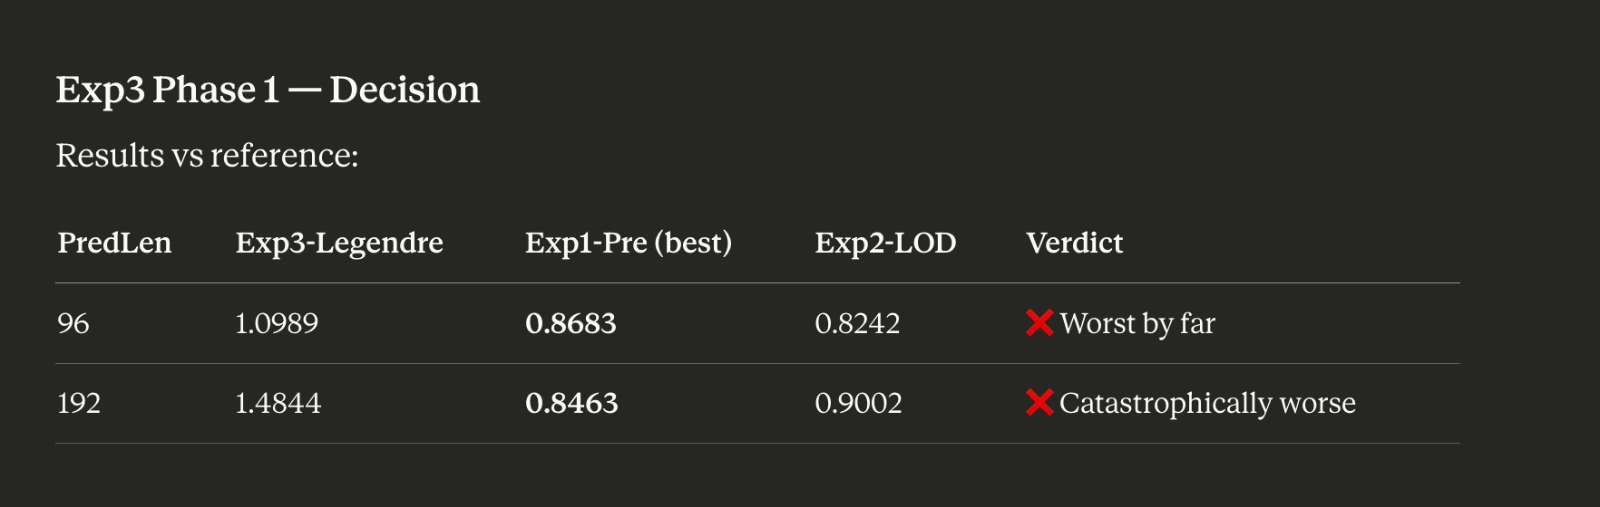

## What to Document for Exp3

Pure Legendre-only embedding (X'_i = X_i + P_i, no temporal embedding) performs significantly worse than all previous experiments — MSE of 1.099 at pred_len=96 vs 0.868 for Exp1-Pre, and 1.484 at pred_len=192 vs 0.846 for Exp1-Pre. Removing temporal embedding entirely eliminates the time-aware signals that ETTh1 forecasting fundamentally depends on. The Legendre label component alone provides no useful positional information when disconnected from temporal context. Phase 2 skipped — clear negative result.

---

## Key Insight for Your Ablation Story

This result actually strengthens your overall narrative. Combined with Exp2, you can now say:

- Legendre alone → terrible (Exp3)  
- Legendre + Distance Operator → unstable, marginal at best (Exp2)  
- Distance decay in attention pre-softmax → consistently best (Exp1-Pre)  

The temporal embedding is non-negotiable. The distance decay in attention is where the real signal comes from.

## Decision: Skip Phase 2. Stop Exp3 here.

This is a clear and decisive negative result — not even close. Exp3 is worse than every previous experiment by a large margin. At pred_len=192 the MSE of 1.48 is nearly double Exp1-Pre's 0.85.

---

## Why it failed

Pure Legendre embedding with no temporal embedding removes all time-aware context. The model loses hourly/daily/monthly signals that ETTh1 heavily depends on. Legendre polynomials provide orthogonal distinctiveness but without temporal grounding the model cannot learn meaningful time patterns. The high train loss (~0.38–0.52 across epochs vs ~0.24 in Exp1) confirms the model is struggling to learn anything useful.